# Resume / Candidate Screening System

## Machine Learning Internship - Future Interns

### Objective

The objective of this project is to build a machine learning based resume screening system that automatically compares candidate resumes with a given job description.

### Key Features

- Resume text preprocessing
- Skill extraction
- Job description parsing
- Resume-to-job similarity scoring
- Candidate ranking
- Missing skill identification
- Business-friendly results

### Technologies Used

- Python
- Pandas
- NumPy
- Scikit-learn
- TF-IDF
- Cosine Similarity
- Google Colab

In [18]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print("Libraries imported successfully!")

Libraries imported successfully!


In [19]:
job_description = """
We are looking for a Machine Learning Engineer.

The candidate should have strong knowledge of Python,
Machine Learning, Deep Learning, SQL, Pandas, NumPy,
Scikit-learn, TensorFlow, Natural Language Processing,
data preprocessing, model evaluation and data visualization.

The candidate should also have good problem solving
and analytical skills.
"""

print(job_description)


We are looking for a Machine Learning Engineer.

The candidate should have strong knowledge of Python,
Machine Learning, Deep Learning, SQL, Pandas, NumPy,
Scikit-learn, TensorFlow, Natural Language Processing,
data preprocessing, model evaluation and data visualization.

The candidate should also have good problem solving
and analytical skills.



In [20]:
required_skills = [
    "python",
    "machine learning",
    "deep learning",
    "sql",
    "pandas",
    "numpy",
    "scikit-learn",
    "tensorflow",
    "natural language processing",
    "data preprocessing",
    "model evaluation",
    "data visualization"
]

print("Required Skills:")
for skill in required_skills:
    print("-", skill)

Required Skills:
- python
- machine learning
- deep learning
- sql
- pandas
- numpy
- scikit-learn
- tensorflow
- natural language processing
- data preprocessing
- model evaluation
- data visualization


In [21]:
resumes = {
    "Candidate A": """
    Python Machine Learning Engineer with experience in machine learning,
    deep learning, SQL, Pandas, NumPy, Scikit-learn and TensorFlow.
    Experienced in data preprocessing, model evaluation and data visualization.
    Worked on NLP projects and predictive analytics.
    Strong problem solving and analytical skills.
    """,

    "Candidate B": """
    Data Analyst with experience in Python, SQL, Pandas, NumPy and data visualization.
    Experienced in data preprocessing and analytics.
    Familiar with machine learning and model evaluation.
    Strong communication and analytical skills.
    """,

    "Candidate C": """
    Software Developer experienced in Java, C++, Python and SQL.
    Worked on web applications and databases.
    Familiar with basic machine learning concepts.
    Experienced in software testing and development.
    """,

    "Candidate D": """
    Machine Learning enthusiast with Python, Machine Learning,
    Pandas, NumPy, Scikit-learn and Natural Language Processing.
    Experienced in data preprocessing, model evaluation and visualization.
    Completed multiple machine learning projects.
    """,

    "Candidate E": """
    Business Analyst with experience in Excel, SQL, data visualization
    and business reporting. Strong analytical and communication skills.
    Limited experience with Python and machine learning.
    """
}

print("Number of resumes:", len(resumes))

Number of resumes: 5


In [22]:
resume_df = pd.DataFrame(
    list(resumes.items()),
    columns=["Candidate", "Resume"]
)

display(resume_df)

,Candidate,Resume
0,Candidate A,\n Python Machine Learning Engineer with ex...
1,Candidate B,"\n Data Analyst with experience in Python, ..."
2,Candidate C,"\n Software Developer experienced in Java, ..."
3,Candidate D,"\n Machine Learning enthusiast with Python,..."
4,Candidate E,\n Business Analyst with experience in Exce...


In [23]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

resume_df["Cleaned_Resume"] = resume_df["Resume"].apply(clean_text)

display(resume_df[["Candidate", "Cleaned_Resume"]])

,Candidate,Cleaned_Resume
0,Candidate A,python machine learning engineer with experien...
1,Candidate B,data analyst with experience in python sql pan...
2,Candidate C,software developer experienced in java c pytho...
3,Candidate D,machine learning enthusiast with python machin...
4,Candidate E,business analyst with experience in excel sql ...


In [24]:
cleaned_job_description = clean_text(job_description)

print(cleaned_job_description)

we are looking for a machine learning engineer the candidate should have strong knowledge of python machine learning deep learning sql pandas numpy scikit learn tensorflow natural language processing data preprocessing model evaluation and data visualization the candidate should also have good problem solving and analytical skills


In [25]:
def extract_skills(text, skills):
    text = text.lower()

    found_skills = []

    for skill in skills:
        if skill.lower() in text:
            found_skills.append(skill)

    return found_skills

resume_df["Matched Skills"] = resume_df["Cleaned_Resume"].apply(
    lambda x: extract_skills(x, required_skills)
)

display(resume_df[["Candidate", "Matched Skills"]])

,Candidate,Matched Skills
0,Candidate A,"[python, machine learning, deep learning, sql,..."
1,Candidate B,"[python, machine learning, sql, pandas, numpy,..."
2,Candidate C,"[python, machine learning, sql]"
3,Candidate D,"[python, machine learning, pandas, numpy, natu..."
4,Candidate E,"[python, machine learning, sql, data visualiza..."


In [26]:
resume_df["Skill Match Count"] = resume_df["Matched Skills"].apply(len)

resume_df["Skill Match Percentage"] = (
    resume_df["Skill Match Count"] /
    len(required_skills) * 100
)

display(
    resume_df[
        [
            "Candidate",
            "Matched Skills",
            "Skill Match Count",
            "Skill Match Percentage"
        ]
    ]
)

,Candidate,Matched Skills,Skill Match Count,Skill Match Percentage
0,Candidate A,"[python, machine learning, deep learning, sql,...",10,83.333333
1,Candidate B,"[python, machine learning, sql, pandas, numpy,...",8,66.666667
2,Candidate C,"[python, machine learning, sql]",3,25.000000
3,Candidate D,"[python, machine learning, pandas, numpy, natu...",7,58.333333
4,Candidate E,"[python, machine learning, sql, data visualiza...",4,33.333333


In [27]:
all_texts = [cleaned_job_description] + resume_df["Cleaned_Resume"].tolist()

vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2)
)

tfidf_matrix = vectorizer.fit_transform(all_texts)

job_vector = tfidf_matrix[0]
resume_vectors = tfidf_matrix[1:]

similarity_scores = cosine_similarity(
    job_vector,
    resume_vectors
).flatten()

resume_df["Similarity Score"] = similarity_scores

display(
    resume_df[
        ["Candidate", "Similarity Score"]
    ]
)

,Candidate,Similarity Score
0,Candidate A,0.550921
1,Candidate B,0.273551
2,Candidate C,0.048950
3,Candidate D,0.398566
4,Candidate E,0.130146


In [28]:
resume_df["Similarity Percentage"] = (
    resume_df["Similarity Score"] * 100
).round(2)

display(
    resume_df[
        ["Candidate", "Similarity Percentage"]
    ]
)

,Candidate,Similarity Percentage
0,Candidate A,55.09
1,Candidate B,27.36
2,Candidate C,4.89
3,Candidate D,39.86
4,Candidate E,13.01


In [29]:
resume_df["Final Score"] = (
    resume_df["Similarity Percentage"] * 0.60
    +
    resume_df["Skill Match Percentage"] * 0.40
)

resume_df["Final Score"] = resume_df["Final Score"].round(2)

display(
    resume_df[
        [
            "Candidate",
            "Skill Match Percentage",
            "Similarity Percentage",
            "Final Score"
        ]
    ]
)

,Candidate,Skill Match Percentage,Similarity Percentage,Final Score
0,Candidate A,83.333333,55.09,66.39
1,Candidate B,66.666667,27.36,43.08
2,Candidate C,25.000000,4.89,12.93
3,Candidate D,58.333333,39.86,47.25
4,Candidate E,33.333333,13.01,21.14


In [30]:
ranked_candidates = resume_df.sort_values(
    by="Final Score",
    ascending=False
).reset_index(drop=True)

ranked_candidates["Rank"] = (
    ranked_candidates.index + 1
)

display(
    ranked_candidates[
        [
            "Rank",
            "Candidate",
            "Final Score",
            "Matched Skills"
        ]
    ]
)

,Rank,Candidate,Final Score,Matched Skills
0,1,Candidate A,66.39,"[python, machine learning, deep learning, sql,..."
1,2,Candidate D,47.25,"[python, machine learning, pandas, numpy, natu..."
2,3,Candidate B,43.08,"[python, machine learning, sql, pandas, numpy,..."
3,4,Candidate E,21.14,"[python, machine learning, sql, data visualiza..."
4,5,Candidate C,12.93,"[python, machine learning, sql]"


In [31]:
def find_missing_skills(matched_skills, required_skills):
    return [
        skill for skill in required_skills
        if skill not in matched_skills
    ]

ranked_candidates["Missing Skills"] = ranked_candidates[
    "Matched Skills"
].apply(
    lambda x: find_missing_skills(
        x,
        required_skills
    )
)

display(
    ranked_candidates[
        [
            "Rank",
            "Candidate",
            "Matched Skills",
            "Missing Skills"
        ]
    ]
)

,Rank,Candidate,Matched Skills,Missing Skills
0,1,Candidate A,"[python, machine learning, deep learning, sql,...","[scikit-learn, natural language processing]"
1,2,Candidate D,"[python, machine learning, pandas, numpy, natu...","[deep learning, sql, scikit-learn, tensorflow,..."
2,3,Candidate B,"[python, machine learning, sql, pandas, numpy,...","[deep learning, scikit-learn, tensorflow, natu..."
3,4,Candidate E,"[python, machine learning, sql, data visualiza...","[deep learning, pandas, numpy, scikit-learn, t..."
4,5,Candidate C,"[python, machine learning, sql]","[deep learning, pandas, numpy, scikit-learn, t..."


In [32]:
final_results = ranked_candidates[
    [
        "Rank",
        "Candidate",
        "Skill Match Percentage",
        "Similarity Percentage",
        "Final Score",
        "Matched Skills",
        "Missing Skills"
    ]
]

display(final_results)

,Rank,Candidate,Skill Match Percentage,Similarity Percentage,Final Score,Matched Skills,Missing Skills
0,1,Candidate A,83.333333,55.09,66.39,"[python, machine learning, deep learning, sql,...","[scikit-learn, natural language processing]"
1,2,Candidate D,58.333333,39.86,47.25,"[python, machine learning, pandas, numpy, natu...","[deep learning, sql, scikit-learn, tensorflow,..."
2,3,Candidate B,66.666667,27.36,43.08,"[python, machine learning, sql, pandas, numpy,...","[deep learning, scikit-learn, tensorflow, natu..."
3,4,Candidate E,33.333333,13.01,21.14,"[python, machine learning, sql, data visualiza...","[deep learning, pandas, numpy, scikit-learn, t..."
4,5,Candidate C,25.000000,4.89,12.93,"[python, machine learning, sql]","[deep learning, pandas, numpy, scikit-learn, t..."


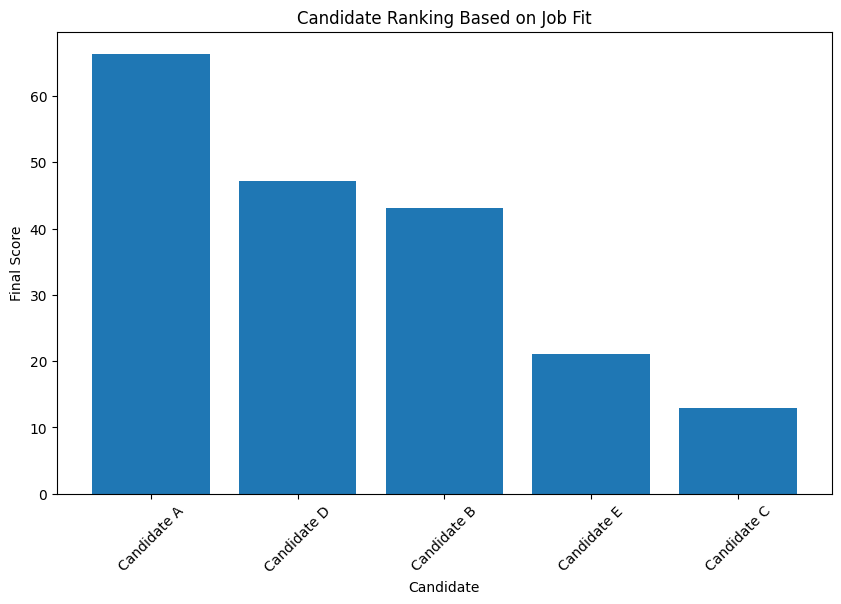

In [33]:
plt.figure(figsize=(10, 6))

plt.bar(
    ranked_candidates["Candidate"],
    ranked_candidates["Final Score"]
)

plt.title("Candidate Ranking Based on Job Fit")
plt.xlabel("Candidate")
plt.ylabel("Final Score")

plt.xticks(rotation=45)

plt.show()

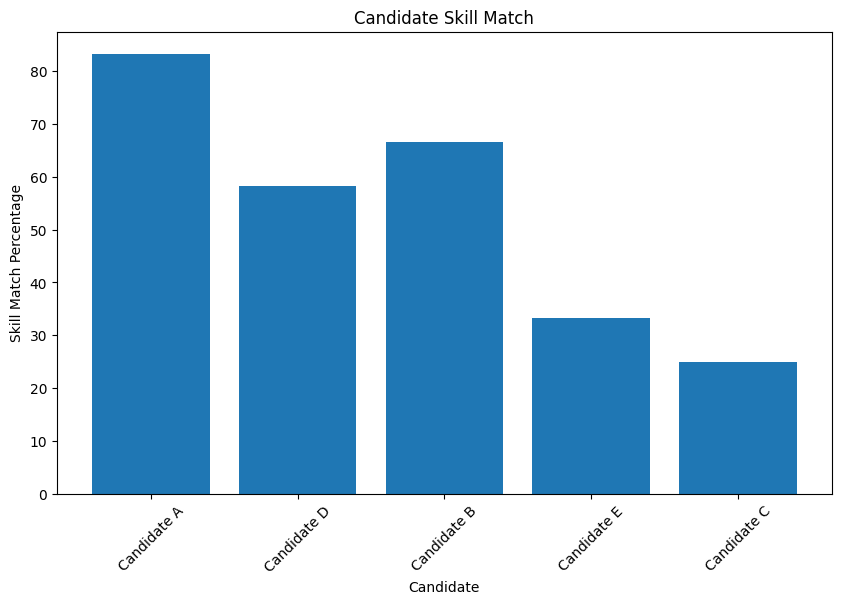

In [34]:
plt.figure(figsize=(10, 6))

plt.bar(
    ranked_candidates["Candidate"],
    ranked_candidates["Skill Match Percentage"]
)

plt.title("Candidate Skill Match")
plt.xlabel("Candidate")
plt.ylabel("Skill Match Percentage")

plt.xticks(rotation=45)

plt.show()

# Business Insights

## Candidate Ranking

The system ranks candidates according to their overall fit for the Machine Learning Engineer role.

The final score combines resume-to-job-description similarity and required skill matching.

## Skill Gap Analysis

The system identifies skills required by the job description that are not present in each candidate's resume.

This allows recruiters to understand both candidate strengths and areas where candidates may need additional training.

## Business Benefits

1. Reduces the time required for initial resume screening.

2. Provides a consistent scoring approach for candidate comparison.

3. Helps recruiters identify candidates with stronger skill alignment.

4. Highlights missing skills for each candidate.

5. Supports data-driven recruitment decisions.

6. Can be extended to process larger numbers of resumes.

## Important Note

This system is designed as a screening support tool. Final hiring decisions should still involve human review and consideration of qualifications, experience and other relevant factors.

# Conclusion

A machine learning based Resume / Candidate Screening System was successfully developed.

The system performs resume text preprocessing, skill extraction, job description analysis, TF-IDF based similarity calculation, candidate scoring, candidate ranking and skill-gap identification.

The system provides recruiters with an explainable way to compare candidates against a specific job role.

The final output includes candidate rankings, matching skills, missing skills and visual comparisons.

This project demonstrates how Natural Language Processing and Machine Learning techniques can support recruitment and candidate screening workflows.

# Technologies Used

- Python
- Pandas
- NumPy
- Regular Expressions
- Scikit-learn
- TF-IDF Vectorization
- Cosine Similarity
- Matplotlib
- Google Colab

# Machine Learning / NLP Techniques

- Text preprocessing
- Keyword-based skill extraction
- TF-IDF feature extraction
- Cosine similarity
- Candidate scoring
- Candidate ranking
- Skill-gap analysis